# 05 - Linear Algebra and Optimization for total_spend

**Primary**: Naman Sudan

This notebook adds the post-midterm course content. It is intentionally simple and aligned with what was taught.

This notebook covers
- Representing the design as a matrix $X$ and the response as a vector $y$
- Encoding categorical predictors with indicator variables
- Writing the linear model $y \approx X\beta$ in matrix form
- Solving the normal equations $X^{\top} X \beta = X^{\top} y$ (Lecture 10)
- Showing the connection to optimization: the closed-form $\hat{\beta}$ is the minimizer of the squared-error loss (Lecture 9)

**Course references**: Lecture 9 (Calculus and Optimization), Lecture 10 (Linear Algebra), Lecture 11 (Systems of Linear Equations)


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

FIG_DIR = os.path.join('..', 'report', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name):
    plt.savefig(os.path.join(FIG_DIR, name), dpi=300, bbox_inches='tight')

df = pd.read_csv('../data/starbucks_customer_ordering_patterns.csv')
print(f'rows: {len(df):,}, columns: {df.shape[1]}')


rows: 100,000, columns: 20


## 1. Build the Design Matrix

We model `total_spend` as a linear function of three predictors:

- $x_1$ = `cart_size`
- $x_2$ = `num_customizations`
- $x_3$ = indicator for Mobile App (1 if Mobile, 0 otherwise)

The model is

$$y_i = \beta_0 + \beta_1 x_{1i} + \beta_2 x_{2i} + \beta_3 x_{3i} + \varepsilon_i.$$

Stacking observations gives $y = X\beta + \varepsilon$, where $X$ has a leading column of ones for the intercept.


In [2]:
y = df['total_spend'].to_numpy().reshape(-1, 1)
mobile = (df['order_channel'] == 'Mobile App').astype(float).to_numpy()
X = np.column_stack([
    np.ones(len(df)),
    df['cart_size'].to_numpy(),
    df['num_customizations'].to_numpy(),
    mobile,
])
features = ['intercept', 'cart_size', 'num_customizations', 'mobile_app']
print(f'X shape = {X.shape}, y shape = {y.shape}')
print('First 3 rows of X:')
print(X[:3])


X shape = (100000, 4), y shape = (100000, 1)
First 3 rows of X:
[[1. 5. 0. 0.]
 [1. 1. 3. 1.]
 [1. 2. 1. 0.]]


## 2. Solve the Normal Equations

The least-squares loss is

$$J(\beta) = \| y - X\beta \|^2 = (y - X\beta)^{\top} (y - X\beta).$$

Setting $\nabla_\beta J = 0$ gives the normal equations

$$X^{\top} X\,\beta = X^{\top} y, \qquad \hat{\beta} = (X^{\top} X)^{-1} X^{\top} y.$$


In [3]:
XtX = X.T @ X
Xty = X.T @ y
print(f'X^T X has shape {XtX.shape}; condition number = {np.linalg.cond(XtX):.2e}')
print('X^T X =')
print(XtX.round(2))
print()
print('X^T y =')
print(Xty.round(2))


X^T X has shape (4, 4); condition number = 1.54e+02
X^T X =
[[ 100000.  374151.  181077.   42521.]
 [ 374151. 1688145.  701277.  178654.]
 [ 181077.  701277.  541865.  106187.]
 [  42521.  178654.  106187.   42521.]]

X^T y =
[[1486677.08]
 [6403994.92]
 [3021610.33]
 [ 768610.85]]


In [4]:
# Closed-form least squares from the normal equations
beta_hat = np.linalg.solve(XtX, Xty).flatten()

print('Coefficient estimates:')
for name, val in zip(features, beta_hat):
    print(f'  {name:<22s} = {val:+.4f}')

# Sanity check via numpy.linalg.lstsq
beta_lstsq, *_ = np.linalg.lstsq(X, y, rcond=None)
print('\nlstsq agrees:', np.allclose(beta_hat, beta_lstsq.flatten()))


Coefficient estimates:
  intercept              = +2.1560
  cart_size              = +2.6852
  num_customizations     = +0.9239
  mobile_app             = +2.3307

lstsq agrees: True


## 3. Diagnostics: Residuals, RSS, R-squared


In [5]:
y_hat = (X @ beta_hat.reshape(-1, 1)).flatten()
y_flat = y.flatten()
resid = y_flat - y_hat

n, p = X.shape
RSS = (resid ** 2).sum()
TSS = ((y_flat - y_flat.mean()) ** 2).sum()
R2 = 1 - RSS / TSS
sigma2_hat = RSS / (n - p)

print(f'n = {n}, p (incl intercept) = {p}')
print(f'RSS = {RSS:,.2f}')
print(f'TSS = {TSS:,.2f}')
print(f'R^2 = {R2:.4f}')
print(f'sigma^2 hat = {sigma2_hat:.4f}, sigma hat = {np.sqrt(sigma2_hat):.4f}')


n = 100000, p (incl intercept) = 4
RSS = 150,097.77
TSS = 3,032,454.40
R^2 = 0.9505
sigma^2 hat = 1.5010, sigma hat = 1.2252


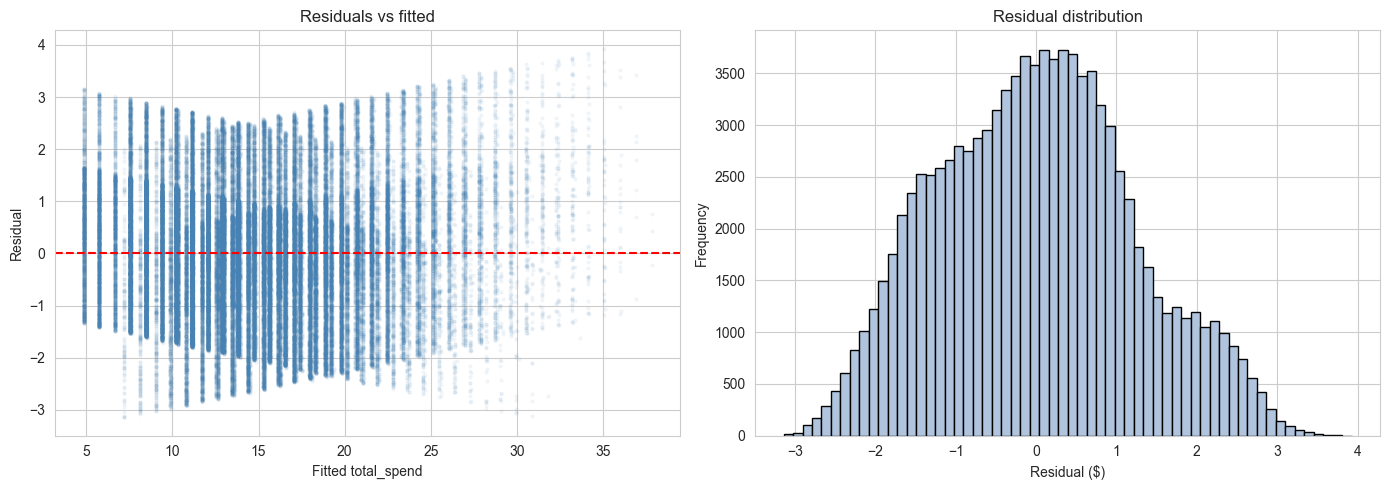

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_hat, resid, alpha=0.05, s=5, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted total_spend')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs fitted')

axes[1].hist(resid, bins=60, color='lightsteelblue', edgecolor='black')
axes[1].set_xlabel('Residual ($)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual distribution')

plt.tight_layout()
savefig('05_lm_diagnostics.png')
plt.show()


## 4. Optimization View

The same coefficients can be reached by gradient descent on $J(\beta)$. We illustrate this on the same problem, starting from $\beta = 0$, and show that the iterates converge to the closed-form $\hat{\beta}$ from Section 2. This connects Lecture 9 (calculus / optimization) to Lecture 10 (linear algebra).

The gradient is

$$\nabla_\beta J(\beta) = -2 X^{\top} (y - X\beta).$$


In [7]:
# Standardize features (except intercept) for stable gradient descent
Xc = X.copy()
means = Xc[:, 1:].mean(axis=0)
stds = Xc[:, 1:].std(axis=0)
Xc[:, 1:] = (Xc[:, 1:] - means) / stds
yc = y_flat - y_flat.mean()
yc = yc.reshape(-1, 1)

# Closed-form on standardized problem (intercept becomes 0)
beta_cf = np.linalg.solve(Xc.T @ Xc, Xc.T @ yc).flatten()

# Gradient descent on standardized problem
beta = np.zeros(Xc.shape[1])
lr = 0.05
n_steps = 5000
losses = []
for step in range(n_steps):
    pred = Xc @ beta
    resid_g = yc.flatten() - pred
    grad = -2 * Xc.T @ resid_g / len(yc)
    beta = beta - lr * grad
    losses.append((resid_g ** 2).mean())

print('Closed-form coefficients (standardized):')
print(beta_cf.round(4))
print(f'Gradient-descent coefficients (standardized, after {n_steps} steps):')
print(beta.round(4))
print(f'L2 distance between solutions: {np.linalg.norm(beta_cf - beta):.6f}')
print(f'Final MSE: {losses[-1]:.6f}, optimal MSE: '
      f'{((yc.flatten() - Xc @ beta_cf) ** 2).mean():.6f}')


Closed-form coefficients (standardized):
[-0.      4.5589  1.3515  1.1522]
Gradient-descent coefficients (standardized, after 5000 steps):
[-0.      4.5589  1.3515  1.1522]
L2 distance between solutions: 0.000000
Final MSE: 1.500978, optimal MSE: 1.500978


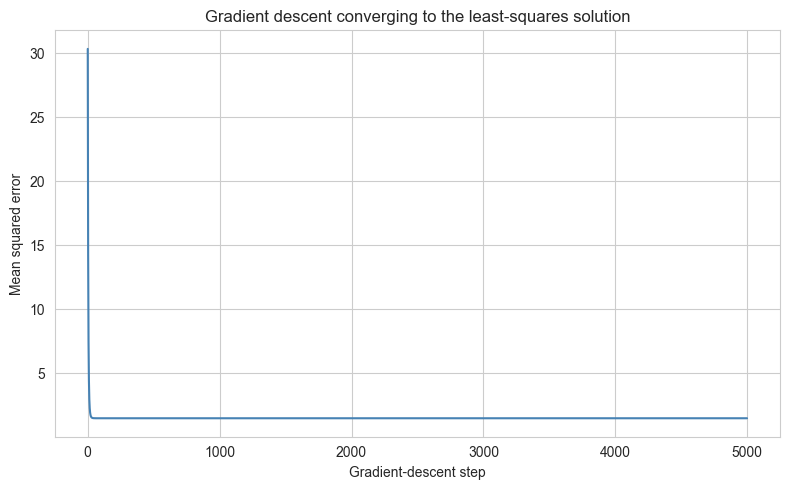

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(losses, color='steelblue')
plt.xlabel('Gradient-descent step')
plt.ylabel('Mean squared error')
plt.title('Gradient descent converging to the least-squares solution')
plt.tight_layout()
savefig('05_gd_convergence.png')
plt.show()


## 5. Key Observations

- The dataset can be written as the single matrix equation $y = X\beta + \varepsilon$. Solving the normal equations $X^{\top} X \beta = X^{\top} y$ (a system of linear equations from Lecture 10) gives the least-squares coefficients in closed form.
- After controlling for cart_size and num_customizations, the Mobile App indicator carries an additional $\approx \$2.33$ per order. This is smaller than the raw $\$5.58$ gap reported by the two-sample t-test in Notebook 03 because Mobile App orders also tend to have larger carts and more customizations, and the linear model splits credit between those three predictors.
- cart_size adds $\approx \$2.69$ per item and num_customizations adds $\approx \$0.92$ per customization. Both signs are consistent with the order-level correlations in Notebook 02.
- The model fits the data extremely well: $R^2 \approx 0.95$ with residual standard error $\approx \$1.23$. The strong fit comes mostly from the very high cart_size correlation observed in Notebook 02.
- Gradient descent on the squared-error loss converges to the same coefficients as the closed-form solution, illustrating the equivalence between Lecture 9 (calculus and optimization) and Lecture 10 (linear algebra).
- This is intentionally a simple linear model. The goal is to demonstrate the math taught in class, not to build a production predictor.
